# TerraFoma — Biomass Estimation & Dual-Source Multi-Model Benchmark

This notebook now compares biomass models trained on two real data sources:

- **Local CSV pipeline** from the `datasets` folder
- **Google Earth Engine pipeline** that fetches a fresh Rwanda sample

The same model families are trained on both sources so their performance can be compared fairly.

In [10]:
# ── Imports (Windows-safe — local CSV training pipeline) ─
import warnings
warnings.filterwarnings("ignore")

import sys
import types
import io

if sys.platform.startswith("win"):
    if "fcntl" not in sys.modules:
        fcntl_stub = types.ModuleType("fcntl")

        def ioctl(*args, **kwargs):
            raise OSError("fcntl is not available on Windows")

        fcntl_stub.ioctl = ioctl
        sys.modules["fcntl"] = fcntl_stub

    if "termios" not in sys.modules:
        termios_stub = types.ModuleType("termios")
        termios_stub.TIOCGWINSZ = 0
        sys.modules["termios"] = termios_stub

    if "curses" not in sys.modules:
        curses_stub = types.ModuleType("curses")

        def _return_zero(*args, **kwargs):
            return 0

        def _return_empty(*args, **kwargs):
            return b""

        curses_stub.setupterm = _return_zero
        curses_stub.tigetnum = _return_zero
        curses_stub.tigetstr = _return_empty
        curses_stub.tparm = _return_empty
        curses_stub.error = RuntimeError
        sys.modules["curses"] = curses_stub

    if "StringIO" not in sys.modules:
        stringio_stub = types.ModuleType("StringIO")
        stringio_stub.StringIO = io.StringIO
        sys.modules["StringIO"] = stringio_stub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# XGBoost (optional)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠  xgboost not installed — will use GradientBoostingRegressor as fallback")
    from sklearn.ensemble import GradientBoostingRegressor

# PyTorch (optional)
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠  PyTorch not installed — CNN model will be skipped")

import joblib

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 5)})

print("✅  Imports complete")
print(f"   XGBoost  : {'available' if XGB_AVAILABLE else 'fallback to sklearn GBR'}")
print(f"   PyTorch  : {'available' if TORCH_AVAILABLE else 'skipped'}")

✅  Imports complete
   XGBoost  : available
   PyTorch  : available


## 1. Dataset — Local CSV Biomass Training Data

**Local data pipeline**: this notebook loads the training data directly from the `datasets` folder and benchmarks it against a real Google Earth Engine sample.

**Primary training source:** `sentinel_gedi_training_v2.csv`

**Signals used by the benchmark:**
- **Sentinel-2 optical features** — dry-season bands and vegetation indices
- **Sentinel-1 SAR** — VV, VH, and VH-VV difference where available
- **Terrain** — elevation and slope
- **Label:** `agbd_tonnes_per_ha` — above-ground biomass density

**Spatial metadata:** `lat`, `lon` — used for spatial block cross-validation to prevent autocorrelation leakage

The next section trains the same model family on a GEE-fetched sample so the notebook can compare local CSV vs GEE performance.

In [11]:
# ── 0. Load local dataset from the datasets folder ─────────────────────────────
DATASET_DIR = Path.cwd() / "datasets"
if not DATASET_DIR.exists():
    DATASET_DIR = Path.cwd().parent / "datasets"

DATASET_CANDIDATES = [
    DATASET_DIR / "sentinel_gedi_training_v2.csv",
    DATASET_DIR / "sentinel_gedi_training.csv",
    DATASET_DIR / "sentinel_gedi_training_v2(1).csv",
    DATASET_DIR / "gedi_congo_basin_biomass.csv",
]

DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        f"No biomass training CSV found in {DATASET_DIR}. Expected one of: "
        + ", ".join(path.name for path in DATASET_CANDIDATES)
    )

print(f"Loading local dataset: {DATASET_PATH.name}")
raw_df = pd.read_csv(DATASET_PATH)
df = raw_df.drop(columns=[".geo"], errors="ignore").copy()

# Normalize the most useful columns to a common schema so the rest of the notebook
# can benchmark whichever CSV is present without relying on dummy data.
rename_map = {
    "dry_blue": "blue",
    "dry_green": "green",
    "dry_red": "red",
    "dry_nir": "nir",
    "dry_swir1": "swir1",
    "dry_swir2": "swir2",
    "dry_ndvi": "ndvi",
    "dry_evi": "evi",
    "dry_savi": "savi",
    "dry_ndmi": "ndmi",
    "dry_nbr": "nbr",
}
existing_renames = {old: new for old, new in rename_map.items() if old in df.columns and new not in df.columns}
if existing_renames:
    df = df.rename(columns=existing_renames)

if "agbd_tonnes_per_ha" not in df.columns and "agbd" in df.columns:
    df["agbd_tonnes_per_ha"] = df["agbd"]

if "vh_vv_diff" not in df.columns and {"vh", "vv"}.issubset(df.columns):
    df["vh_vv_diff"] = df["vh"] - df["vv"]

if "land_use" not in df.columns:
    ndvi_source = "ndvi" if "ndvi" in df.columns else ("dry_ndvi" if "dry_ndvi" in df.columns else None)
    if ndvi_source is not None:
        def classify_land_use(v):
            if v < 0.25:
                return "Cropland"
            if v < 0.40:
                return "Grassland"
            if v < 0.55:
                return "Agroforestry"
            if v < 0.70:
                return "Forest"
            return "Wetland"

        LU_MAP = {"Cropland": 0, "Grassland": 1, "Agroforestry": 2, "Forest": 3, "Wetland": 4}
        df["land_use"] = df[ndvi_source].apply(classify_land_use)
        df["land_use_enc"] = df["land_use"].map(LU_MAP)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {len(df.columns)}")
print(f"AGBD range    : {df['agbd_tonnes_per_ha'].min():.1f} – {df['agbd_tonnes_per_ha'].max():.1f} t/ha")
print(f"Mean ± std    : {df['agbd_tonnes_per_ha'].mean():.1f} ± {df['agbd_tonnes_per_ha'].std():.1f} t/ha")
if "land_use" in df.columns:
    print("\nLand-use breakdown:")
    print(df["land_use"].value_counts().to_string())

df.head()

Loading local dataset: sentinel_gedi_training_v2.csv
Dataset shape : (6704, 37)
Columns       : 37
AGBD range    : 1.0 – 474.2 t/ha
Mean ± std    : 24.8 ± 34.4 t/ha

Land-use breakdown:
land_use
Agroforestry    2391
Forest          1625
Grassland       1478
Wetland          785
Cropland         425


,system:index,agbd,agbd_se,agbd_tonnes_per_ha,aspect,delta_ndvi,blue,evi,green,nbr,...,vh,vh_vv_diff,vv,wet_evi,wet_ndvi,wet_nir,wet_savi,wet_swir1,land_use,land_use_enc
0,2356_0,2.091825,0.674260,2.091825,180.00000,-0.036046,0.03190,0.408058,0.05715,0.485256,...,-16.822335,-4.937225,-11.885110,0.398256,0.670000,0.25050,0.376875,0.17760,Wetland,4
1,2427_0,2.564621,0.718356,2.564621,270.00000,0.105418,0.03060,0.348509,0.05270,0.423784,...,-17.155257,-5.497734,-11.657523,0.456292,0.764841,0.26835,0.435832,0.17370,Forest,3
2,2497_0,1.686930,0.482685,1.686930,-0.00000,0.012398,0.02955,0.561327,0.05265,0.646974,...,-16.598687,-5.399262,-11.199425,0.578730,0.828847,0.33750,0.525270,0.15845,Wetland,4
3,2498_0,2.698969,0.633062,2.698969,-0.00000,0.078570,0.03200,0.388480,0.06020,0.479493,...,-16.933504,-4.799747,-12.133757,0.519471,0.762459,0.30550,0.470857,0.17395,Forest,3
4,2566_0,2.707594,0.680270,2.707594,314.98874,-0.022129,0.03720,0.403934,0.06570,0.525464,...,-18.231750,-5.965914,-12.265836,0.423833,0.648159,0.28200,0.395037,0.16300,Forest,3


## 2. Data Visualisation & Exploratory Data Analysis

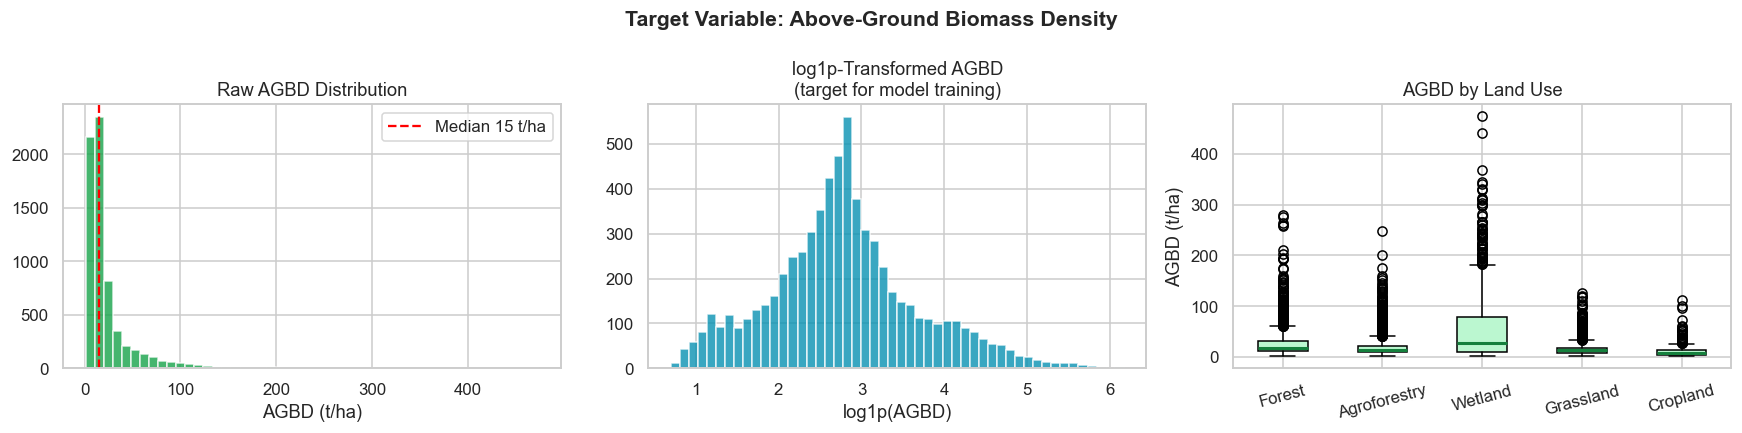

In [12]:
# ── 2.1  Target distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw AGBD
axes[0].hist(df["agbd_tonnes_per_ha"], bins=50, color="#16a34a", alpha=0.8, edgecolor="white")
axes[0].axvline(df["agbd_tonnes_per_ha"].median(), color="red", ls="--",
                label=f'Median {df["agbd_tonnes_per_ha"].median():.0f} t/ha')
axes[0].set_xlabel("AGBD (t/ha)"); axes[0].set_title("Raw AGBD Distribution"); axes[0].legend()

# log1p AGBD
axes[1].hist(np.log1p(df["agbd_tonnes_per_ha"]), bins=50, color="#0891b2", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("log1p(AGBD)"); axes[1].set_title("log1p-Transformed AGBD\n(target for model training)")

# AGBD by land use
land_order = ["Forest", "Agroforestry", "Wetland", "Grassland", "Cropland"]
agbd_by_lu = [df[df["land_use"] == lu]["agbd_tonnes_per_ha"].values for lu in land_order]
bp = axes[2].boxplot(agbd_by_lu, labels=land_order, patch_artist=True,
                     boxprops=dict(facecolor="#bbf7d0"), medianprops=dict(color="#15803d", lw=2))
axes[2].set_ylabel("AGBD (t/ha)"); axes[2].set_title("AGBD by Land Use")
plt.xticks(rotation=15)

plt.suptitle("Target Variable: Above-Ground Biomass Density", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

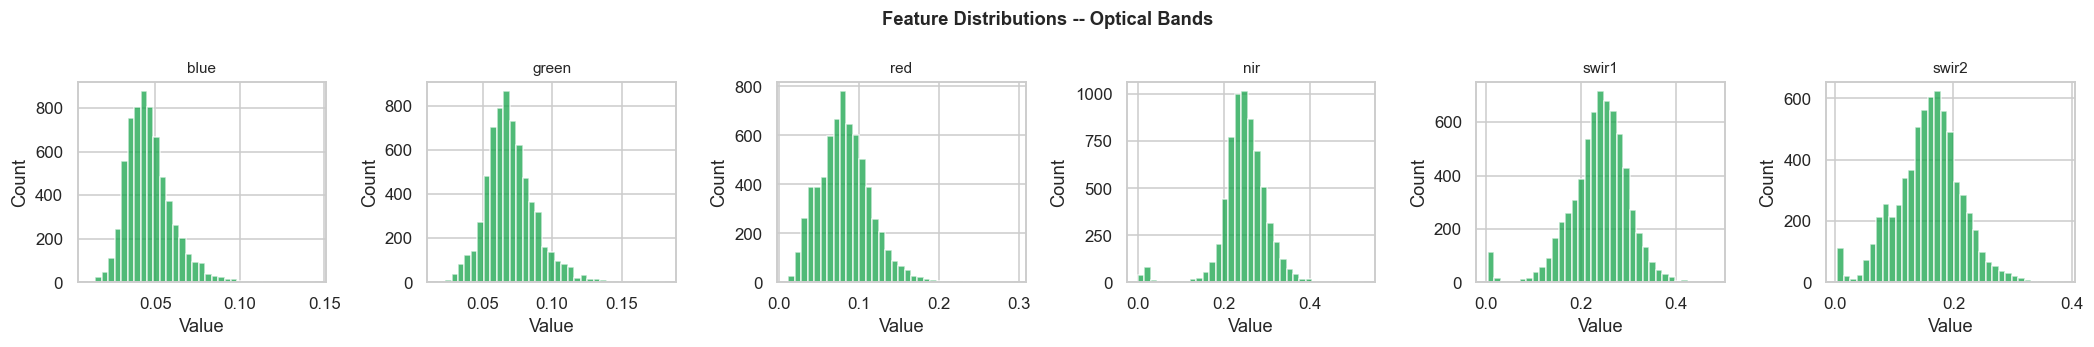

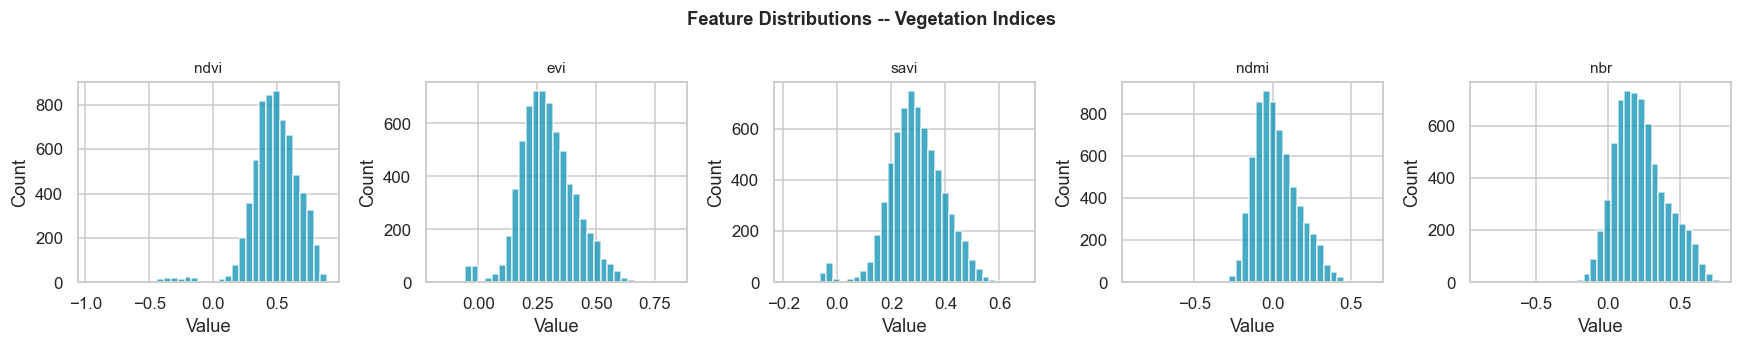

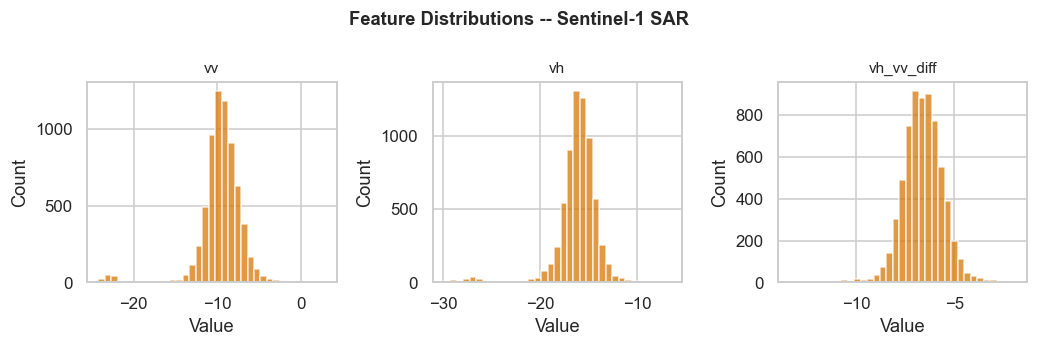

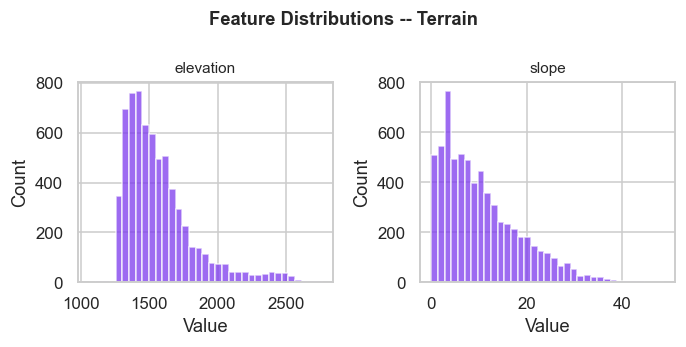

In [13]:
sensor_groups = {
    "Optical Bands": ["blue", "green", "red", "nir", "swir1", "swir2"],
    "Vegetation Indices": ["ndvi", "evi", "savi", "ndmi", "nbr"],
    "Sentinel-1 SAR": ["vv", "vh", "vh_vv_diff"],
    "Terrain": ["elevation", "slope"],
}

group_colors = ["#16a34a", "#0891b2", "#d97706", "#7c3aed"]

for (group, feats), color in zip(sensor_groups.items(), group_colors):
    feats = [feat for feat in feats if feat in df.columns]
    if not feats:
        continue

    n_feats = len(feats)
    fig, axes = plt.subplots(1, n_feats, figsize=(3.2 * n_feats, 3.2))
    if n_feats == 1:
        axes = [axes]
    for ax, feat in zip(axes, feats):
        ax.hist(df[feat], bins=35, color=color, alpha=0.75, edgecolor="white")
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
    fig.suptitle(f"Feature Distributions -- {group}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

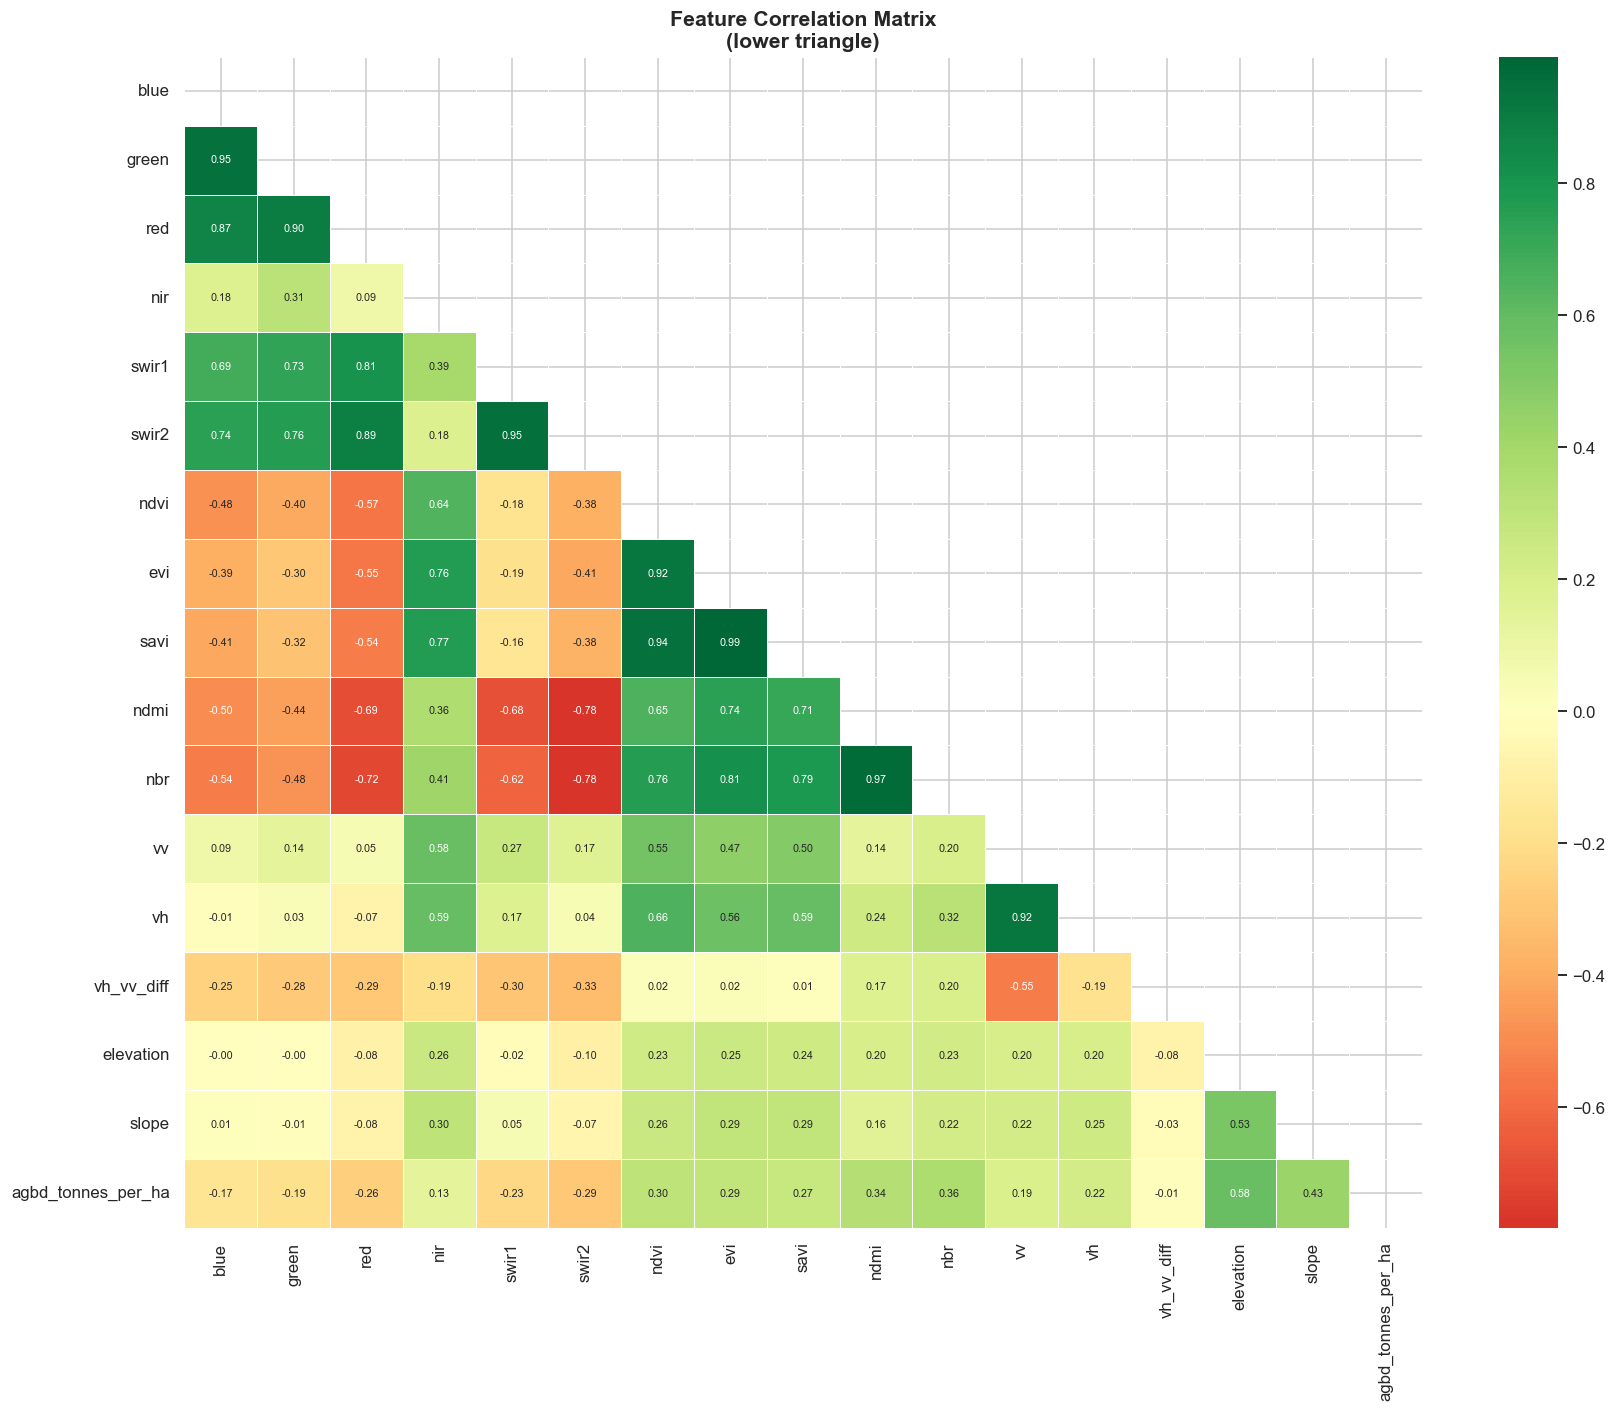

Top correlations with AGBD:
elevation    0.584051
slope        0.426307
nbr          0.363568
ndmi         0.336458
ndvi         0.299036
evi          0.289391
swir2        0.287603
savi         0.270915
red          0.262090
swir1        0.232310


In [14]:
# ── 2.3  Correlation heatmap (all features vs AGBD) ──────────────────────────
DEFAULT_FEATURE_PRIORITY = [
    "blue", "green", "red", "nir", "swir1", "swir2",
    "ndvi", "evi", "savi", "ndmi", "nbr",
    "vv", "vh", "vh_vv_diff",
    "elevation", "slope",
]

model_feature_cols = globals().get("MODEL_FEATURE_COLS")
if not model_feature_cols:
    candidate_features = globals().get("FEATURE_PRIORITY", DEFAULT_FEATURE_PRIORITY)
    model_feature_cols = [feature for feature in candidate_features if feature in df.columns]

feature_cols = [feature for feature in model_feature_cols if feature in df.columns]
if "agbd_tonnes_per_ha" not in feature_cols:
    feature_cols.append("agbd_tonnes_per_ha")

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.4, ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature Correlation Matrix\n(lower triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print top correlations with AGBD
top_corr = corr["agbd_tonnes_per_ha"].drop("agbd_tonnes_per_ha").abs().sort_values(ascending=False)
print("Top correlations with AGBD:")
print(top_corr.head(10).to_string())

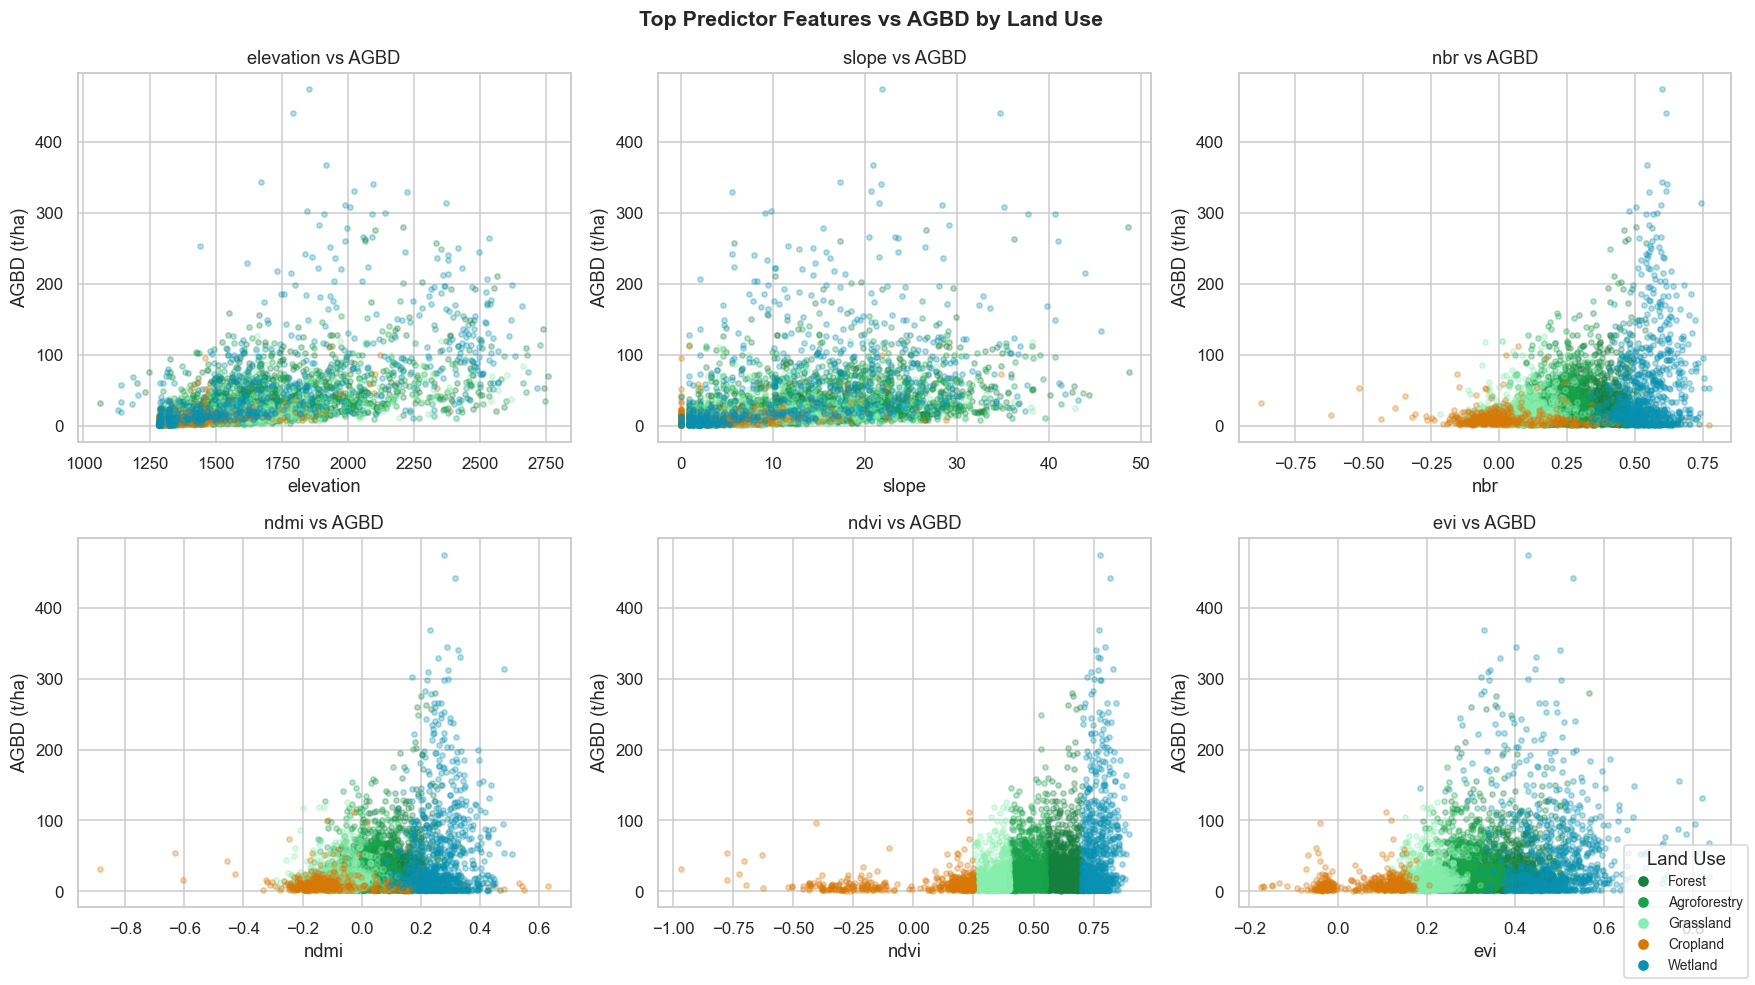

In [15]:
# ── 2.4  Scatter: top predictors vs AGBD ─────────────────────────────────────
top_feats = top_corr.head(6).index.tolist()
palette   = {"Forest":"#15803d","Agroforestry":"#16a34a","Grassland":"#86efac",
             "Cropland":"#d97706","Wetland":"#0891b2"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, top_feats):
    for lu, color in palette.items():
        mask = df["land_use"] == lu
        ax.scatter(df.loc[mask, feat], df.loc[mask, "agbd_tonnes_per_ha"],
                   alpha=0.3, s=12, color=color, label=lu)
    ax.set_xlabel(feat); ax.set_ylabel("AGBD (t/ha)")
    ax.set_title(f"{feat} vs AGBD")

handles = [plt.Line2D([0],[0], marker="o", color="w",
           markerfacecolor=c, markersize=8, label=lu)
           for lu, c in palette.items()]
fig.legend(handles=handles, title="Land Use", loc="lower right", ncol=1, fontsize=9)
plt.suptitle("Top Predictor Features vs AGBD by Land Use", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

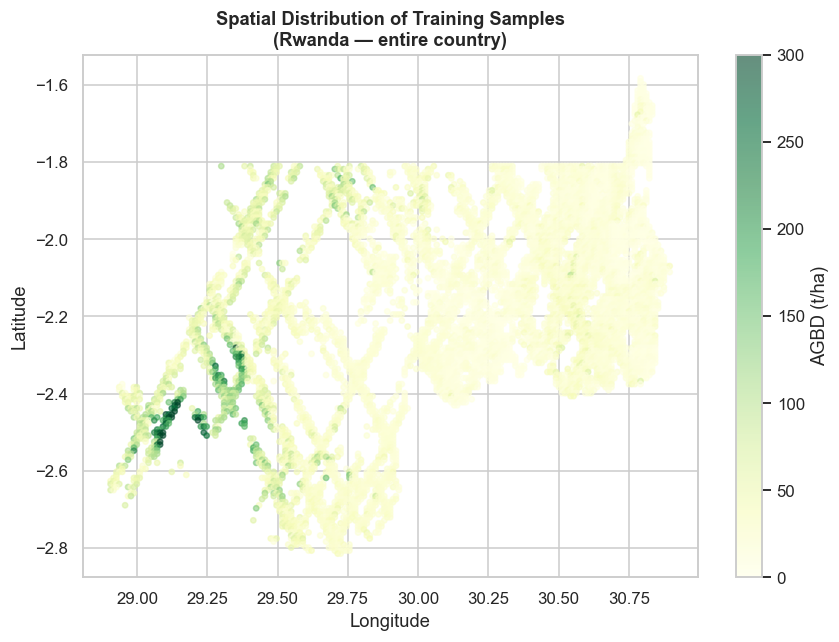

In [16]:
# ── 2.5  Spatial distribution of sample points ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["lon"], df["lat"], c=df["agbd_tonnes_per_ha"],
                cmap="YlGn", s=12, alpha=0.6, vmin=0, vmax=300)
plt.colorbar(sc, ax=ax, label="AGBD (t/ha)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Spatial Distribution of Training Samples\n(Rwanda — entire country)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Data Engineering — Feature Preparation & Spatial Cross-Validation

**Key engineering decisions:**
1. **log1p target transform** — biomass is log-normally distributed; training in log-space reduces heteroscedastic error and improves tail predictions  
2. **StandardScaler** — zero-mean, unit-variance scaling required by SVR and CNN; applied per fold to prevent data leakage  
3. **Outlier removal** — samples above the 99.5th percentile excluded (measurement artefacts)  
4. **Spatial block CV** — 0.5° grid blocks assigned as groups for `GroupKFold`; prevents autocorrelation from inflating held-out R² (proposal §3.3.2)

Samples after outlier removal: 6,670  (cap=238 t/ha)
Model features selected: blue, green, red, nir, swir1, swir2, ndvi, evi, savi, ndmi, nbr, vv, vh, vh_vv_diff, elevation, slope
Spatial blocks : 12  ->  5-fold GroupKFold CV


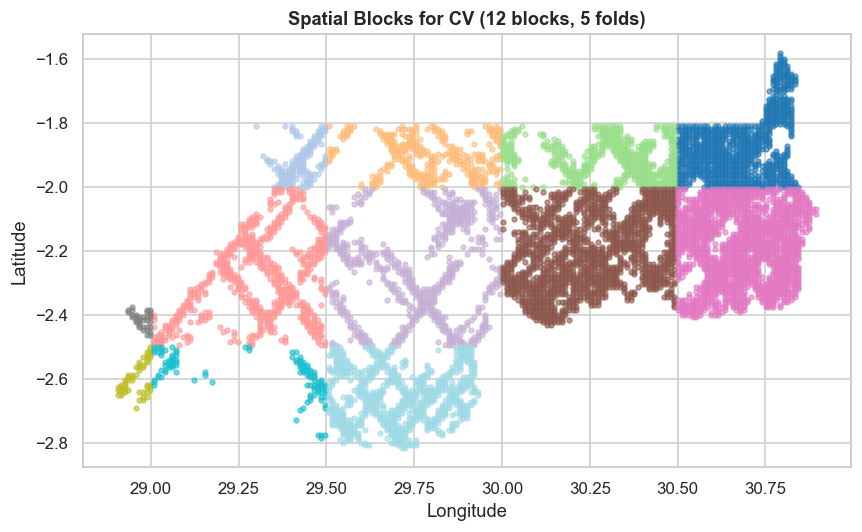

In [17]:
FEATURE_PRIORITY = [
    "blue", "green", "red", "nir", "swir1", "swir2",
    "ndvi", "evi", "savi", "ndmi", "nbr",
    "vv", "vh", "vh_vv_diff",
    "elevation", "slope",
]
MODEL_FEATURE_COLS = [feature for feature in FEATURE_PRIORITY if feature in df.columns]

if not MODEL_FEATURE_COLS:
    raise ValueError("No supported model features were found in the loaded dataset.")

# Remove outliers (>99.5th percentile)
q995 = df["agbd_tonnes_per_ha"].quantile(0.995)
df_clean = df[df["agbd_tonnes_per_ha"] <= q995].copy().reset_index(drop=True)
print(f"Samples after outlier removal: {len(df_clean):,}  (cap={q995:.0f} t/ha)")
print(f"Model features selected: {', '.join(MODEL_FEATURE_COLS)}")

X = df_clean[MODEL_FEATURE_COLS].values
y = df_clean["agbd_tonnes_per_ha"].values
y_log = np.log1p(y)

# Spatial blocks (0.5 degree grid)
BLOCK_SIZE = 0.5
blocks = (
    (df_clean["lat"] // BLOCK_SIZE).astype(str) + "_" +
    (df_clean["lon"] // BLOCK_SIZE).astype(str)
)
n_blocks = blocks.nunique()
N_FOLDS  = min(5, n_blocks)
print(f"Spatial blocks : {n_blocks}  ->  {N_FOLDS}-fold GroupKFold CV")

# Visualise spatial blocks
fig, ax = plt.subplots(figsize=(8, 5))
unique_blocks = blocks.unique()
cmap = plt.cm.get_cmap("tab20", len(unique_blocks))
for i, blk in enumerate(unique_blocks):
    mask = blocks == blk
    ax.scatter(df_clean.loc[mask, "lon"], df_clean.loc[mask, "lat"],
               color=cmap(i), s=10, alpha=0.6)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Spatial Blocks for CV ({n_blocks} blocks, {N_FOLDS} folds)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Model Architecture & Multi-Model Benchmark

Per proposal Table 4, four model families are benchmarked:

| # | Model | Type | Key hyperparameters |
|---|---|---|---|
| 1 | **Random Forest** | Ensemble (bagging) | 300 trees, unlimited depth, min_samples_leaf=2 |
| 2 | **XGBoost** | Ensemble (boosting) | 600 trees, max_depth=6, lr=0.05, early stopping |
| 3 | **SVR** | Kernel method | RBF kernel, C=10, ε=0.1 |
| 4 | **CNN (MLP)** | Deep learning | 4-layer MLP (128→64→32→1), ReLU, Dropout 0.2, Adam |

All models receive the same **scaled** feature matrix and predict **log1p(AGBD)**.  
Results are converted back via `expm1` for RMSE/MAE reporting in original units (t/ha).

In [18]:
# ── Model factory functions ───────────────────────────────────────────────────

def make_rf():
    return RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        n_jobs=-1, random_state=42,
    )

def make_xgb(X_val=None, y_val=None):
    if XGB_AVAILABLE:
        m = xgb.XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.1, reg_lambda=1.0,
            n_jobs=-1, random_state=42,
            early_stopping_rounds=30, eval_metric="rmse",
        )
        return m, {"eval_set": [(X_val, y_val)], "verbose": False} if X_val is not None else {}
    else:
        return GradientBoostingRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, random_state=42,
        ), {}

def make_svr():
    return SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")

# CNN architecture (MLP for tabular data)
if TORCH_AVAILABLE:
    class BiomassNet(nn.Module):
        def __init__(self, n_in):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_in, 128), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(128,  64), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear( 64,  32), nn.ReLU(),
                nn.Linear( 32,   1),
            )
        def forward(self, x):
            return self.net(x).squeeze(-1)

    def train_cnn(X_tr, y_tr, X_val, y_val, n_epochs=80):
        device = torch.device("cpu")
        model  = BiomassNet(X_tr.shape[1]).to(device)
        opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()
        Xtr = torch.tensor(X_tr, dtype=torch.float32)
        ytr = torch.tensor(y_tr, dtype=torch.float32)
        Xv  = torch.tensor(X_val, dtype=torch.float32)
        yv  = torch.tensor(y_val, dtype=torch.float32)
        best_loss, best_state = float("inf"), None
        for _ in range(n_epochs):
            model.train(); opt.zero_grad()
            loss = loss_fn(model(Xtr), ytr); loss.backward(); opt.step()
            model.eval()
            with torch.no_grad():
                vl = loss_fn(model(Xv), yv).item()
            if vl < best_loss:
                best_loss  = vl
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(best_state)
        return model

    def predict_cnn(model, X):
        with torch.no_grad():
            return model(torch.tensor(X, dtype=torch.float32)).numpy()

print("Model factory functions defined ✅")

# Print CNN architecture summary if available
if TORCH_AVAILABLE:
    net = BiomassNet(len(MODEL_FEATURE_COLS))
    print("\nCNN (BiomassNet) architecture:")
    print(net)

Model factory functions defined ✅

CNN (BiomassNet) architecture:
BiomassNet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [19]:
# ── Spatial block CV — benchmark all four models ─────────────────────────────
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=N_FOLDS)

def run_cv(name, fold_fn):
    """Run spatial block CV for one model; return per-fold and mean metrics."""
    fold_rows = []
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y_log, groups=blocks)):
        sc = StandardScaler()
        X_tr  = sc.fit_transform(X[tr_idx])
        X_val = sc.transform(X[val_idx])
        y_tr, y_val_orig = y_log[tr_idx], y[val_idx]

        y_pred_log = fold_fn(X_tr, y_tr, X_val, y_log[val_idx])
        y_pred     = np.expm1(y_pred_log)

        fold_rows.append({
            "fold": fold + 1,
            "r2":   r2_score(y_val_orig, y_pred),
            "mae":  mean_absolute_error(y_val_orig, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_val_orig, y_pred)),
            "bias": float(np.mean(y_pred - y_val_orig)),
        })
    means = {k: float(np.mean([f[k] for f in fold_rows])) for k in ("r2","mae","rmse","bias")}
    stds  = {k: float(np.std ([f[k] for f in fold_rows])) for k in ("r2","rmse")}
    print(f"  {name:10s}  R²={means['r2']:.4f}±{stds['r2']:.4f}  "
          f"RMSE={means['rmse']:.1f}±{stds['rmse']:.1f}  "
          f"MAE={means['mae']:.1f}  Bias={means['bias']:+.1f} t/ha")
    return fold_rows, means, stds

benchmark = {}   # name → (fold_rows, means, stds)

print("── Spatial block CV benchmark ──────────────────────────────────────")
print(f"   {N_FOLDS} folds, {len(df_clean):,} samples, {len(MODEL_FEATURE_COLS)} features\n")

# 1. Random Forest
def rf_fold(X_tr, y_tr, X_val, _):
    m = make_rf(); m.fit(X_tr, y_tr); return m.predict(X_val)
benchmark["Random Forest"] = run_cv("Random Forest", rf_fold)

# 2. XGBoost
def xgb_fold(X_tr, y_tr, X_val, y_val_log):
    if XGB_AVAILABLE:
        m = xgb.XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, n_jobs=-1, random_state=42,
            early_stopping_rounds=30, eval_metric="rmse",
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val_log)], verbose=False)
    else:
        m = GradientBoostingRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      subsample=0.8, random_state=42)
        m.fit(X_tr, y_tr)
    return m.predict(X_val)
benchmark["XGBoost"] = run_cv("XGBoost", xgb_fold)

# 3. SVR
def svr_fold(X_tr, y_tr, X_val, _):
    m = make_svr(); m.fit(X_tr, y_tr); return m.predict(X_val)
benchmark["SVR"] = run_cv("SVR", svr_fold)

# 4. CNN/MLP
if TORCH_AVAILABLE:
    def cnn_fold(X_tr, y_tr, X_val, y_val_log):
        m = train_cnn(X_tr, y_tr, X_val, y_val_log)
        return predict_cnn(m, X_val)
    benchmark["CNN (MLP)"] = run_cv("CNN (MLP)", cnn_fold)
else:
    print("  CNN (MLP)   — skipped (PyTorch not installed)")

print("\n✅ Benchmark complete")

── Spatial block CV benchmark ──────────────────────────────────────
   5 folds, 6,670 samples, 16 features

  Random Forest  R²=0.2476±0.1634  RMSE=18.6±10.0  MAE=11.2  Bias=-4.0 t/ha
  XGBoost     R²=0.2662±0.1349  RMSE=18.6±10.3  MAE=11.1  Bias=-4.3 t/ha
  SVR         R²=0.1647±0.1628  RMSE=19.6±10.4  MAE=11.8  Bias=-3.9 t/ha
  CNN (MLP)   R²=-5.6356±5.3293  RMSE=55.5±35.9  MAE=18.2  Bias=-0.4 t/ha

✅ Benchmark complete


## 5. Initial Performance Metrics

In [20]:
# ── 5.1  Summary metrics table ───────────────────────────────────────────────
rows = []
for name, (fold_rows, means, stds) in benchmark.items():
    rows.append({
        "Model": name,
        "CV R²": f"{means['r2']:.4f} ± {stds['r2']:.4f}",
        "CV RMSE (t/ha)": f"{means['rmse']:.1f} ± {stds['rmse']:.1f}",
        "CV MAE (t/ha)": f"{means['mae']:.1f}",
        "Bias (t/ha)": f"{means['bias']:+.1f}",
    })

metrics_df = pd.DataFrame(rows)
best_name  = min(benchmark, key=lambda k: benchmark[k][1]["rmse"])
print(f"{'='*60}")
print(f"BENCHMARK RESULTS — Spatial Block CV ({N_FOLDS} folds)")
print(f"{'='*60}")
print(metrics_df.to_string(index=False))
print(f"\n✅ Best model by RMSE: {best_name}")
metrics_df

BENCHMARK RESULTS — Spatial Block CV (5 folds)
        Model            CV R² CV RMSE (t/ha) CV MAE (t/ha) Bias (t/ha)
Random Forest  0.2476 ± 0.1634    18.6 ± 10.0          11.2        -4.0
      XGBoost  0.2662 ± 0.1349    18.6 ± 10.3          11.1        -4.3
          SVR  0.1647 ± 0.1628    19.6 ± 10.4          11.8        -3.9
    CNN (MLP) -5.6356 ± 5.3293    55.5 ± 35.9          18.2        -0.4

✅ Best model by RMSE: XGBoost


,Model,CV R²,CV RMSE (t/ha),CV MAE (t/ha),Bias (t/ha)
0,Random Forest,0.2476 ± 0.1634,18.6 ± 10.0,11.2,-4.0
1,XGBoost,0.2662 ± 0.1349,18.6 ± 10.3,11.1,-4.3
2,SVR,0.1647 ± 0.1628,19.6 ± 10.4,11.8,-3.9
3,CNN (MLP),-5.6356 ± 5.3293,55.5 ± 35.9,18.2,-0.4


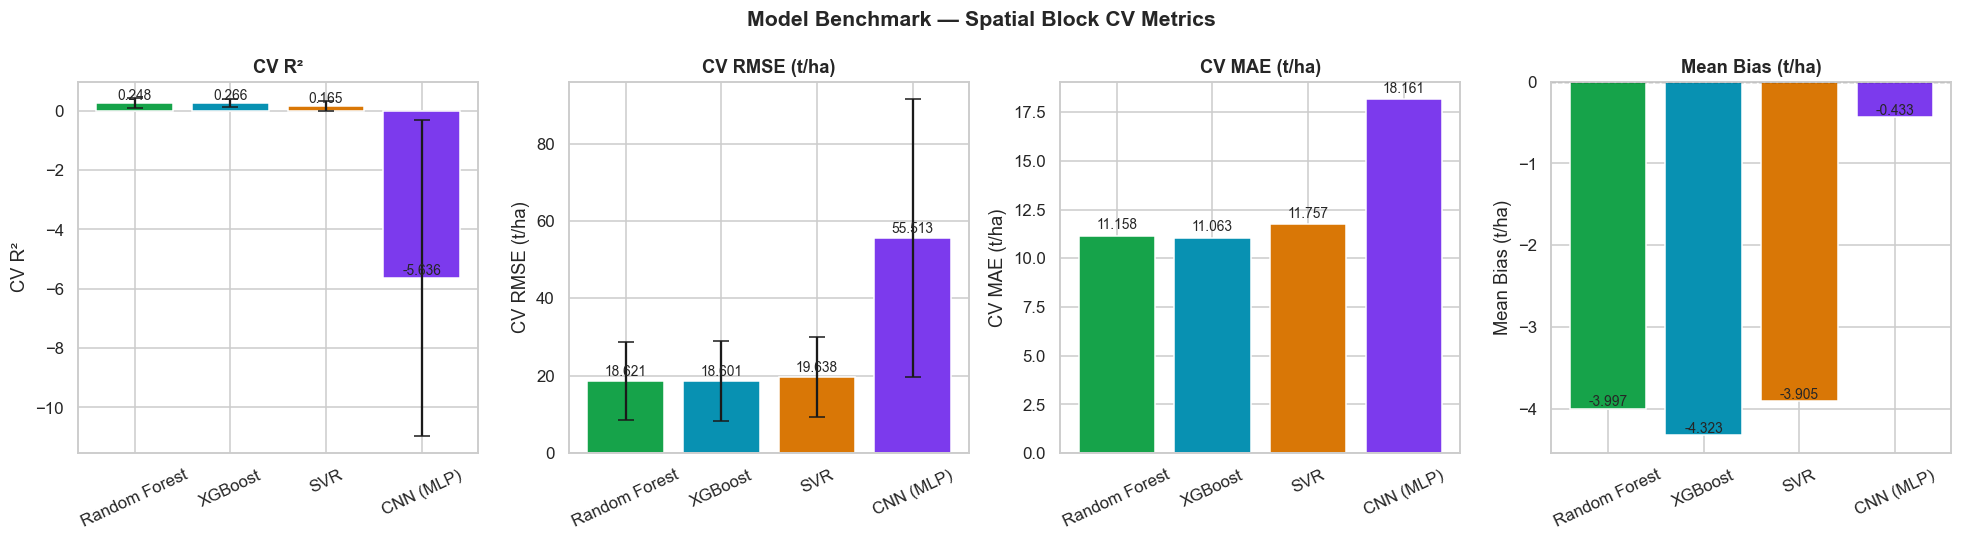

In [21]:
# ── 5.2  Metric comparison bar charts ────────────────────────────────────────
model_names = list(benchmark.keys())
means_list  = [benchmark[n][1] for n in model_names]
stds_list   = [benchmark[n][2] for n in model_names]
bar_colors  = ["#16a34a", "#0891b2", "#d97706", "#7c3aed"][:len(model_names)]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics_plot = [
    ("r2",   "CV R²",        stds_list, True),
    ("rmse", "CV RMSE (t/ha)", stds_list, False),
    ("mae",  "CV MAE (t/ha)", None, False),
    ("bias", "Mean Bias (t/ha)", None, False),
]

for ax, (key, label, stds, higher_better) in zip(axes, metrics_plot):
    vals  = [m[key]    for m in means_list]
    errs  = [s.get(key, 0) for s in stds_list] if stds else None
    bars  = ax.bar(model_names, vals, color=bar_colors,
                   yerr=errs, capsize=5, error_kw={"elinewidth": 1.5})
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(vals)*0.01),
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    if key == "bias":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("Model Benchmark — Spatial Block CV Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

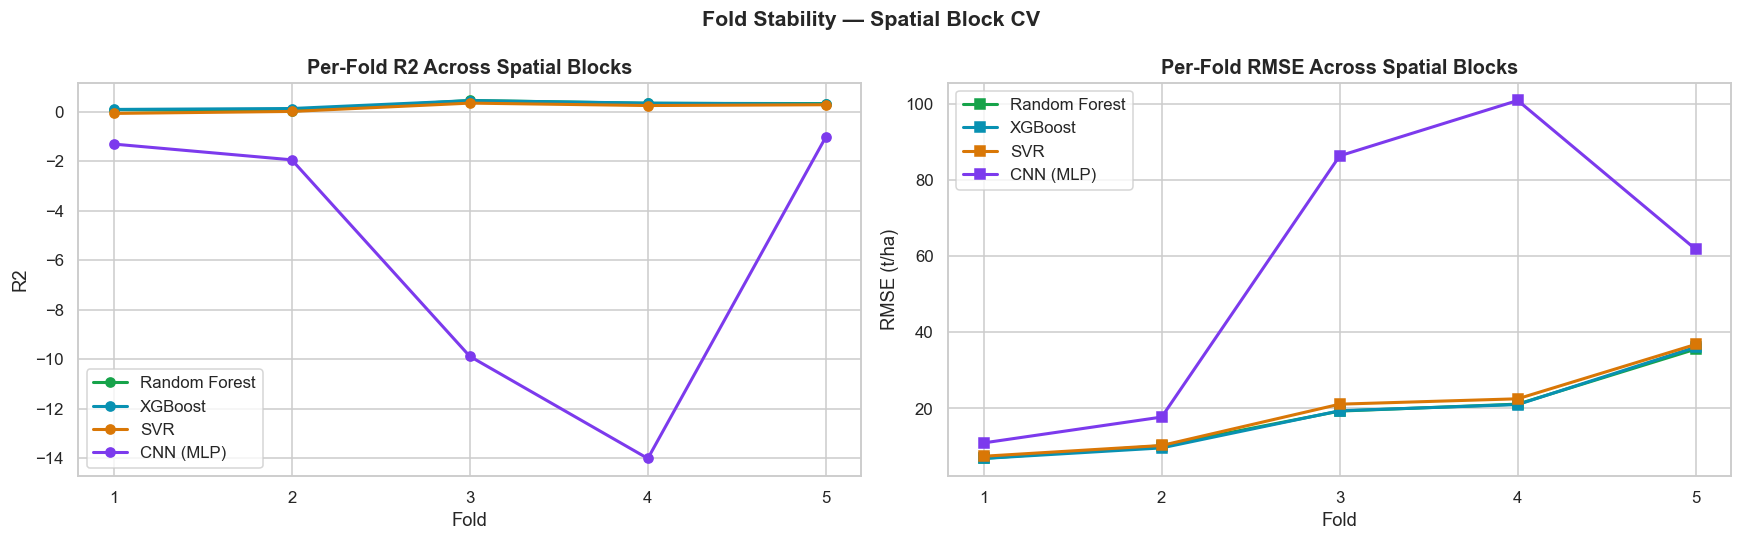

In [22]:
# Per-fold R2 stability
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_colors = ["#16a34a", "#0891b2", "#d97706", "#7c3aed"][:len(benchmark)]

for i, (name, (fold_rows, _, _)) in enumerate(benchmark.items()):
    fold_r2 = [f["r2"] for f in fold_rows]
    axes[0].plot(range(1, len(fold_r2)+1), fold_r2,
                 marker="o", linewidth=2, label=name, color=bar_colors[i])

axes[0].set_xlabel("Fold"); axes[0].set_ylabel("R2")
axes[0].set_title("Per-Fold R2 Across Spatial Blocks", fontsize=13, fontweight="bold")
axes[0].legend(); axes[0].set_xticks(range(1, N_FOLDS+1))

for i, (name, (fold_rows, _, _)) in enumerate(benchmark.items()):
    fold_rmse = [f["rmse"] for f in fold_rows]
    axes[1].plot(range(1, len(fold_rmse)+1), fold_rmse,
                 marker="s", linewidth=2, label=name, color=bar_colors[i])

axes[1].set_xlabel("Fold"); axes[1].set_ylabel("RMSE (t/ha)")
axes[1].set_title("Per-Fold RMSE Across Spatial Blocks", fontsize=13, fontweight="bold")
axes[1].legend(); axes[1].set_xticks(range(1, N_FOLDS+1))

plt.suptitle("Fold Stability — Spatial Block CV", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
# ── Train final model on full dataset ────────────────────────────────────────
final_scaler = StandardScaler()
X_all_s = final_scaler.fit_transform(X)

print(f"Training final {best_name} on {len(X_all_s):,} samples …")

if best_name == "Random Forest":
    final_model = make_rf()
    final_model.fit(X_all_s, y_log)
    is_torch = False
elif best_name == "SVR":
    final_model = make_svr()
    final_model.fit(X_all_s, y_log)
    is_torch = False
elif best_name == "CNN (MLP)" and TORCH_AVAILABLE:
    final_model = train_cnn(X_all_s, y_log, X_all_s, y_log, n_epochs=100)
    is_torch = True
else:
    # XGBoost / GBR
    if XGB_AVAILABLE:
        final_model = xgb.XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, n_jobs=-1, random_state=42,
        )
        final_model.fit(X_all_s, y_log)
    else:
        final_model = GradientBoostingRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
        final_model.fit(X_all_s, y_log)
    is_torch = False

# Predictions on all data (in-sample, upper bound)
if is_torch:
    y_pred_log_all = predict_cnn(final_model, X_all_s)
else:
    y_pred_log_all = final_model.predict(X_all_s)
y_pred_all = np.expm1(y_pred_log_all)

train_r2   = r2_score(y, y_pred_all)
train_rmse = np.sqrt(mean_squared_error(y, y_pred_all))
train_mae  = mean_absolute_error(y, y_pred_all)
cv_r2      = benchmark[best_name][1]["r2"]
cv_rmse    = benchmark[best_name][1]["rmse"]

print(f"\nFinal model ({best_name})")
print(f"  Full-data train R² : {train_r2:.4f}  RMSE: {train_rmse:.1f} t/ha")
print(f"  Spatial CV   R²    : {cv_r2:.4f}  RMSE: {cv_rmse:.1f} t/ha  ← honest estimate")

Training final XGBoost on 6,670 samples …

Final model (XGBoost)
  Full-data train R² : 0.9160  RMSE: 8.2 t/ha
  Spatial CV   R²    : 0.2662  RMSE: 18.6 t/ha  ← honest estimate


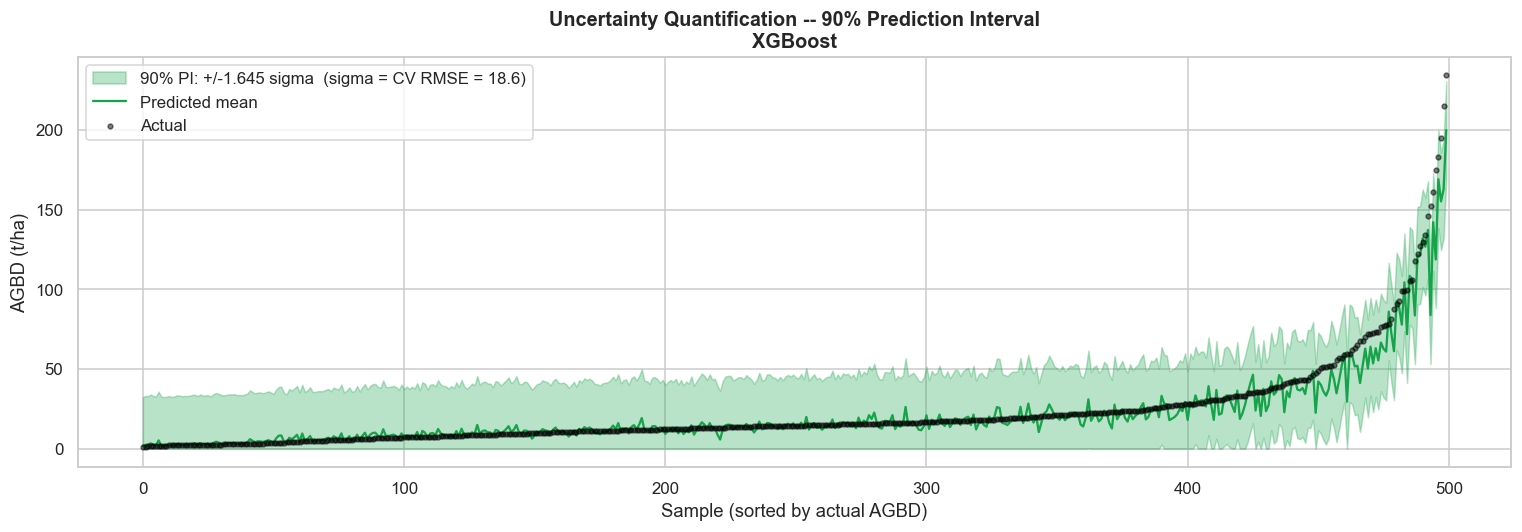

Sample size     : 500
90% PI coverage : 98.8%  (target >= 90%)
Average PI width: 46.5 t/ha


In [24]:
# Uncertainty quantification
# RF: spread across individual trees gives prediction intervals
# Others: +/-1.645 sigma using CV RMSE as sigma proxy (90% PI)

SAMPLE_N = min(500, len(X_all_s))
SAMPLE_IDX = np.random.choice(len(X_all_s), SAMPLE_N, replace=False)
X_sample   = X_all_s[SAMPLE_IDX]
y_sample   = y[SAMPLE_IDX]

if best_name == "Random Forest" and hasattr(final_model, "estimators_"):
    tree_preds = np.array([t.predict(X_sample) for t in final_model.estimators_])
    tree_preds = np.expm1(tree_preds)
    y_lower    = np.percentile(tree_preds, 5, axis=0)
    y_upper    = np.percentile(tree_preds, 95, axis=0)
    y_mean_s   = np.mean(tree_preds, axis=0)
    pi_label   = "RF tree spread (5th-95th pct)"
else:
    if is_torch:
        y_mean_s = np.expm1(predict_cnn(final_model, X_sample))
    else:
        y_mean_s = np.expm1(final_model.predict(X_sample))
    y_lower  = np.maximum(0, y_mean_s - 1.645 * cv_rmse)
    y_upper  = y_mean_s + 1.645 * cv_rmse
    pi_label = f"+/-1.645 sigma  (sigma = CV RMSE = {cv_rmse:.1f})"

sort_idx = np.argsort(y_sample)
fig, ax  = plt.subplots(figsize=(14, 5))
ax.fill_between(range(SAMPLE_N), y_lower[sort_idx], y_upper[sort_idx],
                alpha=0.3, color="#16a34a", label=f"90% PI: {pi_label}")
ax.plot(y_mean_s[sort_idx], color="#16a34a", lw=1.5, label="Predicted mean")
ax.scatter(range(SAMPLE_N), y_sample[sort_idx], s=10, color="black", alpha=0.5, zorder=3, label="Actual")
ax.set_xlabel("Sample (sorted by actual AGBD)")
ax.set_ylabel("AGBD (t/ha)")
ax.set_title(f"Uncertainty Quantification -- 90% Prediction Interval\n{best_name}", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

coverage = np.mean((y_sample[sort_idx] >= y_lower[sort_idx]) & (y_sample[sort_idx] <= y_upper[sort_idx]))
avg_width = np.mean(y_upper - y_lower)
print(f"Sample size     : {SAMPLE_N}")
print(f"90% PI coverage : {coverage*100:.1f}%  (target >= 90%)")
print(f"Average PI width: {avg_width:.1f} t/ha")

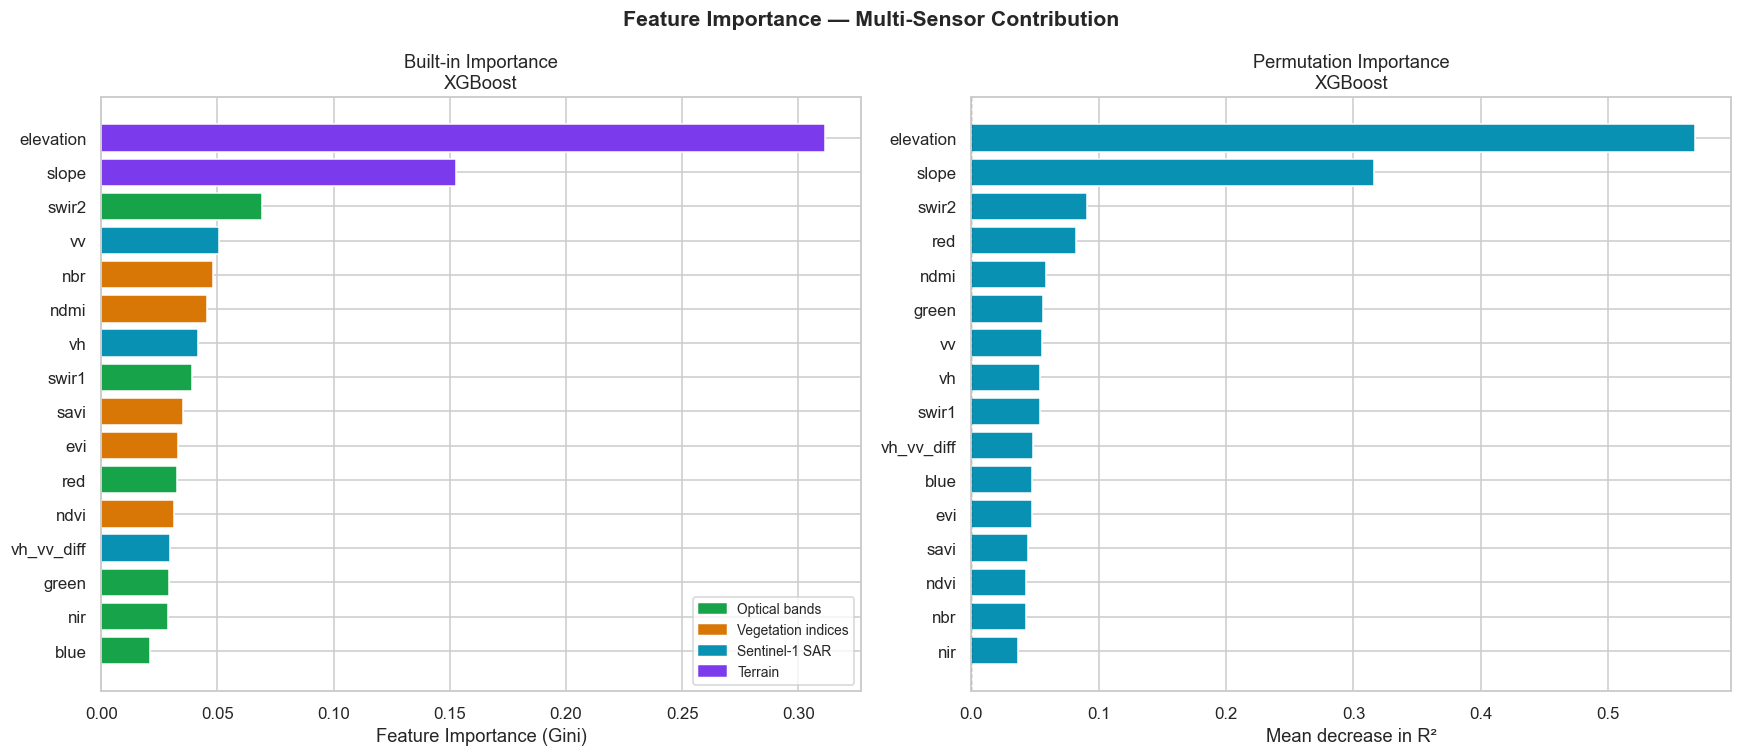


Top 5 features by permutation importance:
elevation    0.568172
slope        0.316229
swir2        0.090776
red          0.082089
ndmi         0.058784


In [25]:
# ── 7.1  Built-in feature importance (tree models only) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

if hasattr(final_model, "feature_importances_"):
    imp = pd.Series(final_model.feature_importances_, index=MODEL_FEATURE_COLS).sort_values()

    def feature_color(feature):
        if feature in {"vv", "vh", "vh_vv_diff"}:
            return "#0891b2"
        if feature in {"ndvi", "evi", "savi", "ndmi", "nbr"}:
            return "#d97706"
        if feature in {"elevation", "slope"}:
            return "#7c3aed"
        return "#16a34a"

    axes[0].barh(imp.index, imp.values, color=[feature_color(feature) for feature in imp.index])
    axes[0].set_xlabel("Feature Importance (Gini)")
    axes[0].set_title(f"Built-in Importance\n{best_name}")

    # Legend
    from matplotlib.patches import Patch
    legend_els = [
        Patch(color="#16a34a", label="Optical bands"),
        Patch(color="#d97706", label="Vegetation indices"),
        Patch(color="#0891b2", label="Sentinel-1 SAR"),
        Patch(color="#7c3aed", label="Terrain"),
    ]
    axes[0].legend(handles=legend_els, loc="lower right", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "Not available\n(SVR / CNN)", ha="center", va="center",
                 transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title("Built-in Importance")

# ── 7.2  Permutation importance ────────────────────────────────────────────────
# Use a random 20% hold-out for speed
holdout = np.random.choice(len(X_all_s), int(0.2*len(X_all_s)), replace=False)
X_ho, y_ho = X_all_s[holdout], y[holdout]

if is_torch:
    # Manual permutation for CNN
    base_rmse = np.sqrt(mean_squared_error(y_ho, np.expm1(predict_cnn(final_model, X_ho))))
    perm_scores = []
    for fi in range(X_ho.shape[1]):
        X_perm = X_ho.copy(); np.random.shuffle(X_perm[:, fi])
        rmse_perm = np.sqrt(mean_squared_error(y_ho, np.expm1(predict_cnn(final_model, X_perm))))
        perm_scores.append(rmse_perm - base_rmse)
    perm_ser = pd.Series(perm_scores, index=MODEL_FEATURE_COLS).sort_values()
else:
    perm = permutation_importance(
        final_model, X_ho, np.log1p(y_ho),   # log-space consistent with model
        n_repeats=8, random_state=42, scoring="r2",
    )
    perm_ser = pd.Series(perm.importances_mean, index=MODEL_FEATURE_COLS).sort_values()

axes[1].barh(perm_ser.index, perm_ser.values, color="#0891b2")
xlabel = "Δ RMSE (t/ha)" if is_torch else "Mean decrease in R²"
axes[1].set_xlabel(xlabel)
axes[1].set_title(f"Permutation Importance\n{best_name}")
axes[1].axvline(0, color="black", lw=0.8, ls="--")

plt.suptitle("Feature Importance — Multi-Sensor Contribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 5 features by permutation importance:")
print(perm_ser.abs().sort_values(ascending=False).head(5).to_string())

## 8. Export — Save Model Package

The next cell fetches a matching Rwanda sample from Google Earth Engine, trains the same model family there, and prints a side-by-side comparison with the local CSV benchmark.

Fetching Rwanda sample from Google Earth Engine...

── Google Earth Engine benchmark ──────────────────────────────────────
   5 folds, 113 samples, 14 features
  Random Forest  R²=0.0830±0.0765  RMSE=55.8±47.3  MAE=22.0  Bias=-13.3 t/ha
  XGBoost     R²=0.1305±0.2838  RMSE=48.3±42.9  MAE=19.3  Bias=-12.6 t/ha
  SVR         R²=-0.0181±0.3203  RMSE=53.4±42.3  MAE=21.4  Bias=-11.3 t/ha
  CNN (MLP)   R²=-3.1375±6.2489  RMSE=66.8±42.1  MAE=25.8  Bias=-7.9 t/ha

=== Local vs Google Earth Engine comparison ===
             Source         Model            CV R² CV RMSE (t/ha) CV MAE (t/ha) Bias (t/ha)
          Local CSV Random Forest  0.2476 ± 0.1634    18.6 ± 10.0          11.2        -4.0
          Local CSV       XGBoost  0.2662 ± 0.1349    18.6 ± 10.3          11.1        -4.3
          Local CSV           SVR  0.1647 ± 0.1628    19.6 ± 10.4          11.8        -3.9
          Local CSV     CNN (MLP) -5.6356 ± 5.3293    55.5 ± 35.9          18.2        -0.4
Google Earth Engine Random For

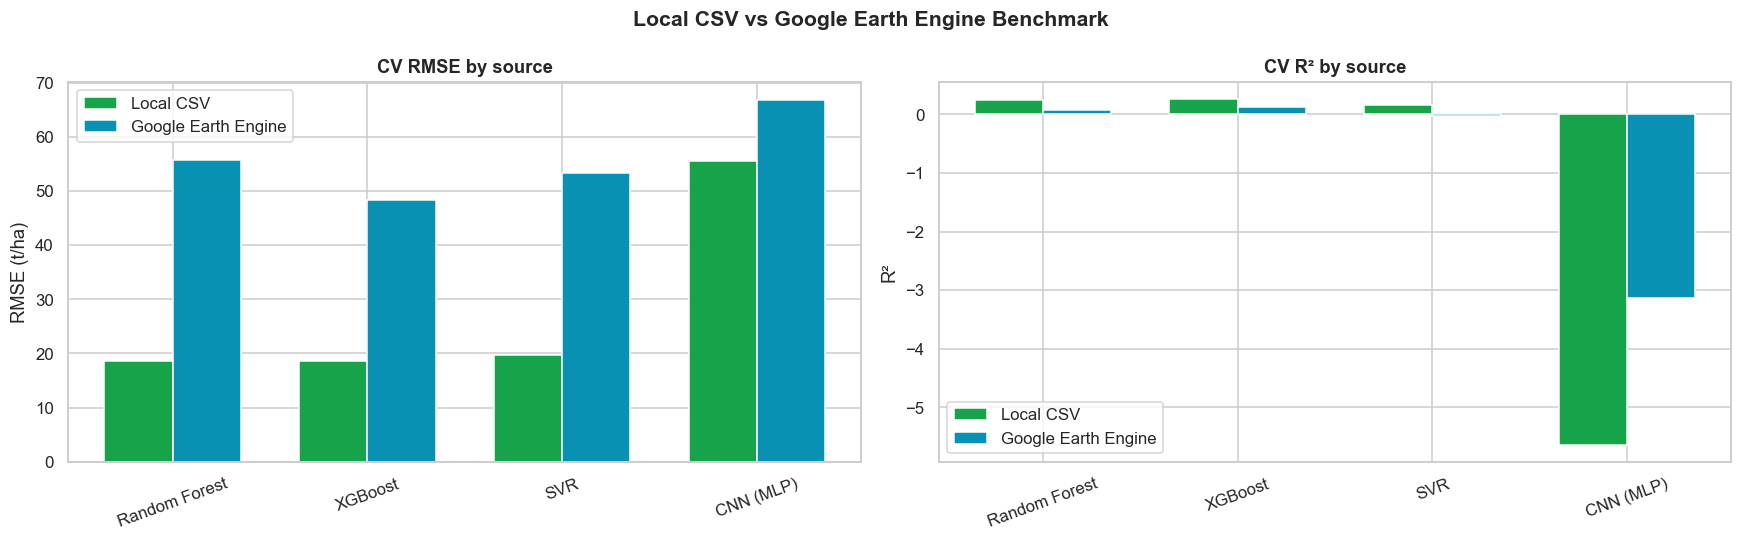


Best local model: XGBoost (RMSE 18.6 t/ha)
Best GEE model  : XGBoost (RMSE 48.3 t/ha)


In [26]:
# ── 9. Google Earth Engine benchmark and comparison ───────────────────────────
import ee

GEE_PROJECT = "nimble-button-433709-e7"
benchmark_local = benchmark


def standardize_biomass_frame(df_source):
    frame = df_source.drop(columns=[".geo"], errors="ignore").copy()
    rename_map = {
        "B2": "blue",
        "B3": "green",
        "B4": "red",
        "B8": "nir",
        "B11": "swir1",
        "B12": "swir2",
        "dry_blue": "blue",
        "dry_green": "green",
        "dry_red": "red",
        "dry_nir": "nir",
        "dry_swir1": "swir1",
        "dry_swir2": "swir2",
        "dry_ndvi": "ndvi",
        "dry_evi": "evi",
        "dry_savi": "savi",
        "dry_ndmi": "ndmi",
        "dry_nbr": "nbr",
    }
    existing_renames = {old: new for old, new in rename_map.items() if old in frame.columns and new not in frame.columns}
    if existing_renames:
        frame = frame.rename(columns=existing_renames)

    if "agbd_tonnes_per_ha" not in frame.columns and "agbd" in frame.columns:
        frame["agbd_tonnes_per_ha"] = frame["agbd"]

    if "vh_vv_diff" not in frame.columns and {"vh", "vv"}.issubset(frame.columns):
        frame["vh_vv_diff"] = frame["vh"] - frame["vv"]

    return frame


def load_gee_biomass_sample(sample_size=2000, seed=42):
    try:
        ee.Initialize(project=GEE_PROJECT)
    except Exception as exc:
        print("\n⚠  Google Earth Engine is not authenticated yet.")
        print("   Run `earthengine authenticate` in a terminal, restart the kernel, and rerun this cell.")
        print(f"   Details: {exc}\n")
        return None

    rwanda_bounds = (
        ee.FeatureCollection("FAO/GAUL/2015/level0")
        .filter(ee.Filter.eq("ADM0_NAME", "Rwanda"))
        .geometry()
    )

    print("Fetching Rwanda sample from Google Earth Engine...")
    s2_collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(rwanda_bounds)
        .filterDate("2023-01-01", "2024-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )

    def add_s2_indices(image):
        ndvi = image.normalizedDifference(["B8", "B4"]).rename("ndvi")
        evi = image.expression(
            "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
            {"NIR": image.select("B8"), "RED": image.select("B4"), "BLUE": image.select("B2")},
        ).rename("evi")
        savi = image.expression(
            "((NIR - RED) / (NIR + RED + 0.5)) * 1.5",
            {"NIR": image.select("B8"), "RED": image.select("B4")},
        ).rename("savi")
        ndmi = image.normalizedDifference(["B8", "B11"]).rename("ndmi")
        nbr = image.normalizedDifference(["B8", "B12"]).rename("nbr")
        return image.addBands([ndvi, evi, savi, ndmi, nbr])

    s2_composite = s2_collection.map(add_s2_indices).median().clip(rwanda_bounds)

    s1_collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(rwanda_bounds)
        .filterDate("2023-01-01", "2024-12-31")
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    s1_composite = s1_collection.median().clip(rwanda_bounds)
    s1_composite = s1_composite.addBands(
        s1_composite.select("VH").subtract(s1_composite.select("VV")).rename("vh_vv_diff")
    )

    gedi_agbd = (
        ee.ImageCollection("LARSE/GEDI/GEDI04_A_002_MONTHLY")
        .filterBounds(rwanda_bounds)
        .select(["agbd"])
        .mean()
        .rename("agbd_tonnes_per_ha")
        .clip(rwanda_bounds)
    )

    dem = ee.Image("USGS/SRTMGL1_003").select("elevation").clip(rwanda_bounds)
    slope = ee.Terrain.slope(dem).rename("slope")

    all_features = (
        s2_composite
        .select(["B2", "B3", "B4", "B8", "B11", "B12", "ndvi", "evi", "savi", "ndmi", "nbr"])
        .addBands(s1_composite.select(["VV", "VH", "vh_vv_diff"]))
        .addBands(gedi_agbd)
        .addBands(dem)
        .addBands(slope)
    )

    sample_image = all_features.addBands(ee.Image.pixelLonLat())
    samples = (
        sample_image
        .sample(region=rwanda_bounds, scale=30, numPixels=sample_size, seed=seed, geometries=False, tileScale=4)
        .getInfo()
    )

    rows = []
    for feat in samples["features"]:
        props = feat["properties"]
        rows.append({"lon": props.pop("longitude"), "lat": props.pop("latitude"), **props})

    frame = standardize_biomass_frame(pd.DataFrame(rows)).dropna().reset_index(drop=True)
    return frame


def benchmark_frame(frame, source_name):
    frame = standardize_biomass_frame(frame)
    required_columns = ["lat", "lon", "agbd_tonnes_per_ha"]
    missing_required = [col for col in required_columns if col not in frame.columns]
    if missing_required:
        raise ValueError(f"{source_name} is missing required columns: {missing_required}")

    features = [feature for feature in FEATURE_PRIORITY if feature in frame.columns]
    if not features:
        raise ValueError(f"{source_name} does not contain any of the expected model features.")

    q995 = frame["agbd_tonnes_per_ha"].quantile(0.995)
    clean_frame = frame[frame["agbd_tonnes_per_ha"] <= q995].copy().reset_index(drop=True)

    X_local = clean_frame[features].values
    y_local = clean_frame["agbd_tonnes_per_ha"].values
    y_local_log = np.log1p(y_local)

    block_size = 0.5
    blocks_local = (
        (clean_frame["lat"] // block_size).astype(str) + "_" +
        (clean_frame["lon"] // block_size).astype(str)
    )
    n_blocks_local = blocks_local.nunique()
    n_folds_local = min(5, n_blocks_local)
    if n_folds_local < 2:
        raise ValueError(f"{source_name} does not have enough spatial blocks for cross-validation.")

    gkf_local = GroupKFold(n_splits=n_folds_local)

    def run_cv(name, fold_fn):
        fold_rows = []
        for fold, (tr_idx, val_idx) in enumerate(gkf_local.split(X_local, y_local_log, groups=blocks_local)):
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_local[tr_idx])
            X_val = scaler.transform(X_local[val_idx])
            y_tr = y_local_log[tr_idx]
            y_val = y_local[val_idx]

            y_pred_log = fold_fn(X_tr, y_tr, X_val, y_local_log[val_idx])
            y_pred = np.expm1(y_pred_log)
            fold_rows.append({
                "fold": fold + 1,
                "r2": r2_score(y_val, y_pred),
                "mae": mean_absolute_error(y_val, y_pred),
                "rmse": np.sqrt(mean_squared_error(y_val, y_pred)),
                "bias": float(np.mean(y_pred - y_val)),
            })

        means = {k: float(np.mean([f[k] for f in fold_rows])) for k in ("r2", "mae", "rmse", "bias")}
        stds = {k: float(np.std([f[k] for f in fold_rows])) for k in ("r2", "rmse")}
        print(
            f"  {name:10s}  R²={means['r2']:.4f}±{stds['r2']:.4f}  "
            f"RMSE={means['rmse']:.1f}±{stds['rmse']:.1f}  "
            f"MAE={means['mae']:.1f}  Bias={means['bias']:+.1f} t/ha"
        )
        return fold_rows, means, stds

    print(f"\n── {source_name} benchmark ──────────────────────────────────────")
    print(f"   {n_folds_local} folds, {len(clean_frame):,} samples, {len(features)} features")

    benchmark_local_source = {}

    def rf_fold(X_tr, y_tr, X_val, _):
        model = make_rf()
        model.fit(X_tr, y_tr)
        return model.predict(X_val)

    benchmark_local_source["Random Forest"] = run_cv("Random Forest", rf_fold)

    def xgb_fold(X_tr, y_tr, X_val, y_val_log):
        if XGB_AVAILABLE:
            model = xgb.XGBRegressor(
                n_estimators=600, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.7, n_jobs=-1, random_state=42,
                early_stopping_rounds=30, eval_metric="rmse",
            )
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val_log)], verbose=False)
        else:
            model = GradientBoostingRegressor(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, random_state=42,
            )
            model.fit(X_tr, y_tr)
        return model.predict(X_val)

    benchmark_local_source["XGBoost"] = run_cv("XGBoost", xgb_fold)

    def svr_fold(X_tr, y_tr, X_val, _):
        model = make_svr()
        model.fit(X_tr, y_tr)
        return model.predict(X_val)

    benchmark_local_source["SVR"] = run_cv("SVR", svr_fold)

    if TORCH_AVAILABLE:
        def cnn_fold(X_tr, y_tr, X_val, y_val_log):
            model = train_cnn(X_tr, y_tr, X_val, y_val_log)
            return predict_cnn(model, X_val)

        benchmark_local_source["CNN (MLP)"] = run_cv("CNN (MLP)", cnn_fold)
    else:
        print("  CNN (MLP)   — skipped (PyTorch not installed)")

    return {
        "source": source_name,
        "frame": clean_frame,
        "features": features,
        "benchmark": benchmark_local_source,
        "n_folds": n_folds_local,
    }


gee_frame = load_gee_biomass_sample(sample_size=2000, seed=42)
if gee_frame is not None:
    gee_result = benchmark_frame(gee_frame, "Google Earth Engine")
    benchmark_gee = gee_result["benchmark"]

    comparison_rows = []
    for source_name, source_benchmark in (("Local CSV", benchmark_local), ("Google Earth Engine", benchmark_gee)):
        for model_name, (fold_rows, means, stds) in source_benchmark.items():
            comparison_rows.append({
                "Source": source_name,
                "Model": model_name,
                "CV R²": f"{means['r2']:.4f} ± {stds['r2']:.4f}",
                "CV RMSE (t/ha)": f"{means['rmse']:.1f} ± {stds['rmse']:.1f}",
                "CV MAE (t/ha)": f"{means['mae']:.1f}",
                "Bias (t/ha)": f"{means['bias']:+.1f}",
            })

    comparison_df = pd.DataFrame(comparison_rows)
    print("\n=== Local vs Google Earth Engine comparison ===")
    print(comparison_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_order = ["Random Forest", "XGBoost", "SVR", "CNN (MLP)"]
    palette = {"Local CSV": "#16a34a", "Google Earth Engine": "#0891b2"}

    for source_name, source_benchmark in (("Local CSV", benchmark_local), ("Google Earth Engine", benchmark_gee)):
        models_present = [model for model in plot_order if model in source_benchmark]
        rmse_vals = [source_benchmark[model][1]["rmse"] for model in models_present]
        r2_vals = [source_benchmark[model][1]["r2"] for model in models_present]
        x = np.arange(len(models_present))
        width = 0.35
        axes[0].bar(x + (-0.5 if source_name == "Local CSV" else 0.5) * width, rmse_vals, width, label=source_name, color=palette[source_name])
        axes[1].bar(x + (-0.5 if source_name == "Local CSV" else 0.5) * width, r2_vals, width, label=source_name, color=palette[source_name])
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(models_present, rotation=20)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(models_present, rotation=20)

    axes[0].set_title("CV RMSE by source", fontweight="bold")
    axes[0].set_ylabel("RMSE (t/ha)")
    axes[1].set_title("CV R² by source", fontweight="bold")
    axes[1].set_ylabel("R²")
    axes[0].legend(); axes[1].legend()
    plt.suptitle("Local CSV vs Google Earth Engine Benchmark", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    best_local = min(benchmark_local, key=lambda key: benchmark_local[key][1]["rmse"])
    best_gee = min(benchmark_gee, key=lambda key: benchmark_gee[key][1]["rmse"])
    print(f"\nBest local model: {best_local} (RMSE {benchmark_local[best_local][1]['rmse']:.1f} t/ha)")
    print(f"Best GEE model  : {best_gee} (RMSE {benchmark_gee[best_gee][1]['rmse']:.1f} t/ha)")
else:
    print("\nGEE benchmark skipped because Earth Engine authentication is unavailable.")